In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("churn-bigml-80.csv")

print(df.head())
print(df.info())
print(df.isnull().sum())

  State  Account length  Area code International plan Voice mail plan  \
0    KS             128        415                 No             Yes   
1    OH             107        415                 No             Yes   
2    NJ             137        415                 No              No   
3    OH              84        408                Yes              No   
4    OK              75        415                Yes              No   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1             27.47   

In [2]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])

print(df.head())

   State  Account length  Area code  International plan  Voice mail plan  \
0     16             128        415                   0                1   
1     35             107        415                   0                1   
2     31             137        415                   0                0   
3     35              84        408                   1                0   
4     36              75        415                   1                0   

   Number vmail messages  Total day minutes  Total day calls  \
0                     25              265.1              110   
1                     26              161.6              123   
2                      0              243.4              114   
3                      0              299.4               71   
4                      0              166.7              113   

   Total day charge  Total eve minutes  Total eve calls  Total eve charge  \
0             45.07              197.4               99             16.78   
1   

In [3]:
from sklearn.model_selection import train_test_split

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(2132, 19)
(534, 19)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [5]:
from sklearn.linear_model import LogisticRegression

# Create model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

LogisticRegression()

In [6]:
# Predictions
y_pred = model.predict(X_test)

print(y_pred[:10])

[ True False False False False False False False False False]


In [7]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)

Accuracy: 0.8595505617977528
Precision: 0.5625
Recall: 0.22784810126582278


ROC AUC Score: 0.7770482681875087


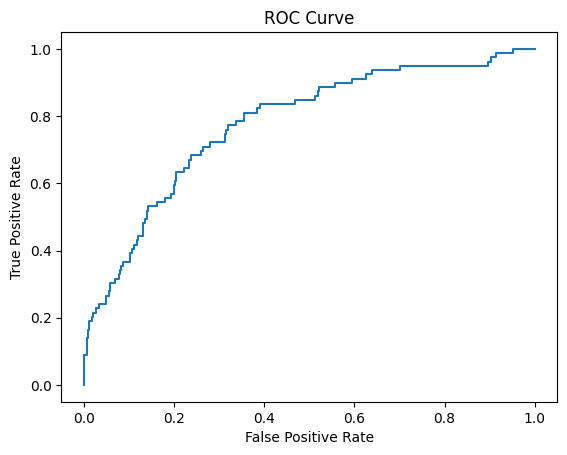

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probability predictions
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# ROC AUC score
auc = roc_auc_score(y_test, y_prob)

print("ROC AUC Score:", auc)

# Plot ROC curve
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [9]:
import numpy as np

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0],
    'Odds Ratio': np.exp(model.coef_[0])
})

print(coefficients)

                   Feature  Coefficient  Odds Ratio
0                    State     0.000479    1.000479
1           Account length     0.041977    1.042870
2                Area code    -0.053273    0.948121
3       International plan     0.667418    1.949199
4          Voice mail plan    -0.766362    0.464701
5    Number vmail messages     0.328090    1.388315
6        Total day minutes     0.371052    1.449259
7          Total day calls     0.074447    1.077289
8         Total day charge     0.370157    1.447962
9        Total eve minutes     0.144267    1.155193
10         Total eve calls     0.014832    1.014943
11        Total eve charge     0.142849    1.153555
12     Total night minutes     0.076498    1.079500
13       Total night calls    -0.035473    0.965149
14      Total night charge     0.074716    1.077578
15      Total intl minutes     0.139844    1.150095
16        Total intl calls    -0.281862    0.754377
17       Total intl charge     0.150671    1.162614
18  Customer